# 03 Feature Engineering

## Ziel

In diesem Notebook wird der zuvor bereinigte Datensatz um zusätzliche Merkmale 
(Features) erweitert. Ziel ist es, die zeitlichen, energiewirtschaftlichen und 
preisbezogenen Eigenschaften des deutschen Strommarktes systematisch abzubilden.

Die erzeugten Features sind fachlich interpretierbar und dienen als Grundlage für 
die anschließende Datenanalyse, SQL-basierte Auswertungen und das Power-BI-Dashboard.

Im Mittelpunkt stehen insbesondere:

- zeitliche Merkmale zur Abbildung von Tages-, Wochen- und Jahresmustern
- energiewirtschaftliche Kennzahlen zur Beschreibung der Stromerzeugung und -nachfrage
- Merkmale zur Charakterisierung der Residuallast
- Kennzahlen zum Anteil erneuerbarer Energien
- verzögerte Strompreise (Lag-Features)
- rollierende statistische Kennzahlen zur Beschreibung der Preisentwicklung

Die Verarbeitung erfolgt reproduzierbar mit Python und Pandas.

## 1. Ausgangsdaten

Als Ausgangspunkt dient der im Rahmen der Datenbereinigung erzeugte Datensatz 
aus dem vorherigen Verarbeitungsschritt.

Die Daten enthalten unter anderem:

- Zeitstempel
- Day-Ahead-Strompreis
- Windenergie (Onshore und Offshore)
- Solarenergie
- Stromnachfrage (Load)

Vor der Feature-Erzeugung werden zunächst der Datentyp des Zeitstempels, der 
betrachtete Untersuchungszeitraum sowie die zeitliche Auflösung überprüft.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/energy_hourly_2023_2025.csv"
)
# In diesem Fall explicit UTC Zeitzone verwenden, damit Zeitreihenfeatures zuverlässing funktionieren
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)


In [5]:
df.head()

,timestamp,price,wind_offshore,wind_onshore,solar,load,wind
0,2022-12-31 23:00:00+00:00,-5.17,3060.925,27360.450,0.00,38346.050,30421.375
1,2023-01-01 00:00:00+00:00,-1.07,3588.425,27965.775,0.00,37777.200,31554.200
2,2023-01-01 01:00:00+00:00,-1.47,3844.575,27897.050,0.00,36939.925,31741.625
3,2023-01-01 02:00:00+00:00,-5.08,3465.125,25986.475,0.00,35932.375,29451.600
4,2023-01-01 03:00:00+00:00,-4.49,3464.275,25462.150,1.05,35486.250,28926.425


In [9]:
#Überprüfung des Datensatzes
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isna().sum())

print(
    "\nDuplicate timestamps:",
    df["timestamp"].duplicated().sum()
)

print(
    "\nStart:",
    df["timestamp"].min()
)

print(
    "End:",
    df["timestamp"].max()
)
print(df.columns.tolist())

Shape: (26328, 7)

Missing Values:
timestamp        0
price            0
wind_offshore    0
wind_onshore     0
solar            0
load             0
wind             0
dtype: int64

Duplicate timestamps: 0

Start: 2022-12-31 23:00:00+00:00
End: 2026-01-01 22:00:00+00:00
['timestamp', 'price', 'wind_offshore', 'wind_onshore', 'solar', 'load', 'wind']


# Zeitliche Features
Aus den bestehneden Zeitstempeln sollen weitere Merkmale abgeleitet werden. Damit kann später der Datensatz nach Jahr, Monat, Tageszeit und Wochentag analysiert werden und diese könen später auch als Eingangsvariablen für machine learning Modelle verwendet werden. 

In [54]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"] >= 5

# Erneuerbare Energien 
Führe wind und Solarenergie zu einer gemeinsamen Größe zusammen. 

In [12]:
df["renewable_generation"] = (
    df["wind"] + df["solar"]
)

In [13]:
df[
    [
        "wind",
        "solar",
        "renewable_generation"
    ]
].head()

,wind,solar,renewable_generation
0,30421.375,0.00,30421.375
1,31554.200,0.00,31554.200
2,31741.625,0.00,31741.625
3,29451.600,0.00,29451.600
4,28926.425,1.05,28927.475


# Residual Load 

residual load beschreibt die verbleibende Stromnachfrage, nach Berücksichtigung der Wind -und Solarerzeugung

In [14]:
df["residual_load"] = (
    df["load"] - df["renewable_generation"]
)

In [15]:
df[
    [
        "load",
        "renewable_generation",
        "residual_load"
    ]
].head()

,load,renewable_generation,residual_load
0,38346.050,30421.375,7924.675
1,37777.200,31554.200,6223.000
2,36939.925,31741.625,5198.300
3,35932.375,29451.600,6480.775
4,35486.250,28927.475,6558.775


# Erneuerbarer Anteil 

$
\text{RenewableShare}_t
=
\frac{\text{RenewableGeneration}_t}
{\text{Load}_t}
$

In [16]:
df["renewable_share"] = (
    df["renewable_generation"]
    / df["load"]
)

In [17]:
df["renewable_share"].describe()

count    26328.000000
mean         0.424820
std          0.242067
min          0.002068
25%          0.224285
50%          0.403410
75%          0.599471
max          1.151696
Name: renewable_share, dtype: float64

In [18]:
df["renewable_share_pct"] = (
    df["renewable_share"] * 100
)

In [19]:
df["renewable_share_pct"].describe()

count    26328.000000
mean        42.482017
std         24.206747
min          0.206785
25%         22.428496
50%         40.340984
75%         59.947105
max        115.169560
Name: renewable_share_pct, dtype: float64

# Preisbezogene Features 

Wir erzeugen verzögerte Preisvariablen, da wir in der EDA gesehen haben dass die Preisvariablen deutliche zeitliche Abhängigkeiten aufweisen. 

In [22]:
#lag1 
df["price_lag_1"] = (
    df["price"].shift(1)
)

In [23]:
#lag24 
df["price_lag_24"] = (
    df["price"].shift(24)
)

In [24]:
#lag 168
df["price_lag_168"] = (
    df["price"].shift(168)
)

# Rolling features 
bilde gleitende statistische Kennzahlen um kurzfristige Preisentwicklungen und Volatilität abzubilden

In [28]:
#24 Stunden Mittelwert 
df["price_rolling_mean_24h"] = (
    df["price"]
    .rolling(window=24)
    .mean()
)
#24 Stunden Standardabweichung 
df["price_rolling_std_24h"] = (
    df["price"]
    .rolling(window=24)
    .std()
)

Aufpassen auf Look-Ahead-Bias: \
Bei der Verwendung der Features für zukünftige PRognosen, dürfen keine Informationen aus der Zukunt verwendet werden. 
\
Durch die rollingfeatures entstehen zwangsläufig fehlende Werte. 

In [29]:
df.isna().sum()

timestamp                   0
price                       0
wind_offshore               0
wind_onshore                0
solar                       0
load                        0
wind                        0
year                        0
month                       0
day                         0
hour                        0
day_of_week                 0
renewable_generation        0
residual_load               0
renewable_share             0
renewable_share_pct         0
price_lag_1                 1
price_lag_24               24
price_lag_168             168
price_rolling_std_24h      23
price_rolling_mean_24h     23
dtype: int64

Wir entfernen die ersten Zeilen, für die die längste Historie noch nicht vorhanden ist. 
wir haben eine 168 stunden lag variable berechnet daher faleln die ersten 168 Beobachtugnen raus 

In [30]:
df = df.dropna().copy()
df.isna().sum()

# Feature Übersicht 


In [34]:
df.columns.tolist()

['timestamp',
 'price',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'load',
 'wind',
 'year',
 'month',
 'day',
 'hour',
 'day_of_week',
 'renewable_generation',
 'residual_load',
 'renewable_share',
 'renewable_share_pct',
 'price_lag_1',
 'price_lag_24',
 'price_lag_168',
 'price_rolling_std_24h',
 'price_rolling_mean_24h']

In [35]:
feature_groups = {
    "Temporal": [
        "year",
        "month",
        "day",
        "hour",
        "day_of_week",
        "is_weekend"
    ],
    "Energy": [
        "renewable_generation",
        "residual_load",
        "renewable_share_pct"
    ],
    "Price": [
        "price_lag_1",
        "price_lag_24",
        "price_lag_168",
        "price_rolling_mean_24h",
        "price_rolling_std_24h"
    ]
}

feature_groups

{'Temporal': ['year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend'],
 'Energy': ['renewable_generation', 'residual_load', 'renewable_share_pct'],
 'Price': ['price_lag_1',
  'price_lag_24',
  'price_lag_168',
  'price_rolling_mean_24h',
  'price_rolling_std_24h']}

In [37]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,26160.0,87.55,51.33,-500.00,65.01,90.02,112.78,936.28
wind_offshore,26160.0,2853.11,1929.40,0.00,1122.58,2597.36,4456.96,8237.78
wind_onshore,26160.0,12568.16,9723.67,45.82,4831.07,9970.66,18187.12,47795.28
solar,26160.0,7016.27,10676.11,0.00,0.60,237.18,11352.81,49713.88
load,26160.0,52835.74,9130.47,30902.68,45335.26,52878.00,59704.77,75635.23
wind,26160.0,15421.28,10975.18,45.85,6422.42,12843.89,22412.47,52173.80
year,26160.0,2024.01,0.82,2023.00,2023.00,2024.00,2025.00,2026.00
month,26160.0,6.55,3.43,1.00,4.00,7.00,10.00,12.00
day,26160.0,15.79,8.78,1.00,8.00,16.00,23.00,31.00
hour,26160.0,11.50,6.92,0.00,5.75,11.50,17.25,23.00


In [39]:
new_features = [
    "renewable_generation",
    "residual_load",
    "renewable_share_pct",
    "price_lag_1",
    "price_lag_24",
    "price_lag_168",
    "price_rolling_mean_24h",
    "price_rolling_std_24h"
]

df[new_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
renewable_generation,26160.0,22437.54,13183.06,127.62,11197.89,21105.19,32269.15,63657.98
residual_load,26160.0,30398.19,13727.35,-6406.35,20851.34,30752.75,39842.39,68313.08
renewable_share_pct,26160.0,42.39,24.22,0.21,22.32,40.18,59.88,115.17
price_lag_1,26160.0,87.55,51.33,-500.00,65.01,90.02,112.78,936.28
price_lag_24,26160.0,87.62,51.28,-500.00,65.14,90.05,112.78,936.28
price_lag_168,26160.0,87.64,51.45,-500.00,64.97,90.06,113.10,936.28
price_rolling_mean_24h,26160.0,87.58,35.37,-53.87,66.83,88.36,106.26,396.89
price_rolling_std_24h,26160.0,32.80,19.11,1.14,20.29,28.96,42.38,262.94


# Untersuche Zusammenhänge der neuen Features 

In [41]:
correlation_features = [
    "price",
    "wind",
    "solar",
    "load",
    "renewable_generation",
    "residual_load",
    "renewable_share_pct"
]

corr = df[correlation_features].corr()

corr.round(3)

,price,wind,solar,load,renewable_generation,residual_load,renewable_share_pct
price,1.000,-0.356,-0.432,0.322,-0.646,0.835,-0.757
wind,-0.356,1.000,-0.259,0.159,0.623,-0.492,0.596
solar,-0.432,-0.259,1.000,0.189,0.594,-0.445,0.561
load,0.322,0.159,0.189,1.000,0.285,0.391,0.017
renewable_generation,-0.646,0.623,0.594,0.285,1.000,-0.770,0.950
residual_load,0.835,-0.492,-0.445,0.391,-0.770,1.000,-0.901
renewable_share_pct,-0.757,0.596,0.561,0.017,0.950,-0.901,1.000


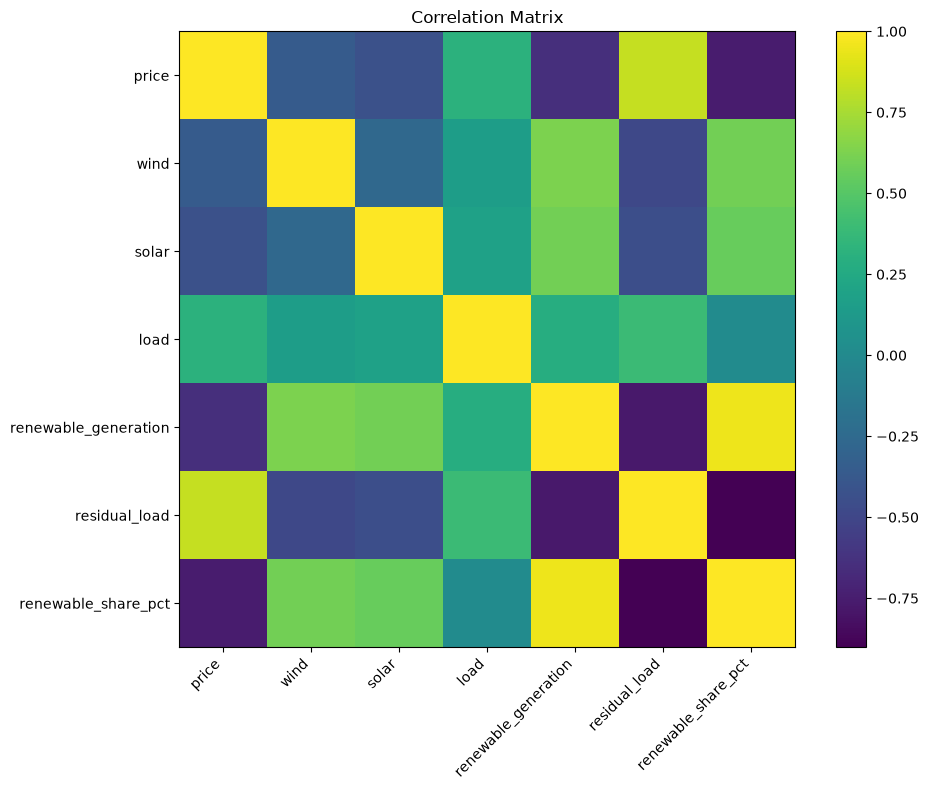

In [42]:
plt.figure(figsize=(10, 8))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

Interpretation: \

Residuallast und Strompreis: starke positive Korrelation (Wenn also viel Strom nachgefragt wird und gleichzeitig wenig Wind- und Solarstrom verfügbar ist, muss mehr konventionelle bzw. teurere Erzeugung eingesetzt werden. Das kann mit höheren Day-Ahead-Preisen einhergehen.) \


negative Korrelation zwischen erneuerbaren Energie und Strompreis: Eine hohe Verfügbarkeit von Erneuerbaren Energien, geht tendenziell mit niedrigen Strompreisen einher. (Aber hier nur Korrelation) \
 
Korrelatio zwischen Preis und erneuerbarer Anteil relativ hoch \

Korrelation zwischen erneuerbaren Strom erzeugung und erneuerbarer Anteil sehr hoch -> vorsicht, da Features mathematisch miteineadner verbunden sind \

Korrelatio zwischen Residual load und erneuerbarer Anteil sehrhoch -> Features ebenfalls mathematisch miteinader verbunden \

renewable_share_pct, renewable_generation , residual_load enthalten teilweise dieselben informationen (Multikolinearität) 


# Plausibilitätscheck

In [43]:
(
    df["renewable_generation"]
    < 0
).sum()

np.int64(0)

In [44]:
(
    df["load"]
    <= 0
).sum()

np.int64(0)

In [45]:
df["renewable_share_pct"].describe()

count    26160.000000
mean        42.394818
std         24.221117
min          0.206785
25%         22.322508
50%         40.179215
75%         59.876451
max        115.169560
Name: renewable_share_pct, dtype: float64

In [46]:
df[df["renewable_share_pct"] > 100][
    [
        "timestamp",
        "price",
        "wind",
        "solar",
        "load",
        "renewable_generation",
        "residual_load",
        "renewable_share_pct"
    ]
].sort_values("renewable_share_pct", ascending=False).head(20)

,timestamp,price,wind,solar,load,renewable_generation,residual_load,renewable_share_pct
22860,2025-08-10 11:00:00+00:00,-61.080,5563.550,40283.350,39808.175,45846.900,-6038.725,115.169560
21853,2025-06-29 12:00:00+00:00,-24.010,11364.975,38143.750,43102.375,49508.725,-6406.350,114.863102
22861,2025-08-10 12:00:00+00:00,-50.940,5917.800,39003.450,39120.925,44921.250,-5800.325,114.826656
22862,2025-08-10 13:00:00+00:00,-22.120,8099.400,36070.550,38495.600,44169.950,-5674.350,114.740256
22859,2025-08-10 10:00:00+00:00,-40.030,6264.800,40684.975,40963.325,46949.775,-5986.450,114.614170
11677,2024-05-01 12:00:00+00:00,-120.070,9792.725,36078.625,40227.125,45871.350,-5644.225,114.030893
11676,2024-05-01 11:00:00+00:00,-120.000,9248.350,38018.125,41513.300,47266.475,-5753.175,113.858631
21852,2025-06-29 11:00:00+00:00,-20.100,10287.100,38941.525,44261.275,49228.625,-4967.350,111.222790
21854,2025-06-29 13:00:00+00:00,-15.450,12843.850,35595.700,43558.725,48439.550,-4880.825,111.205160
11678,2024-05-01 13:00:00+00:00,-79.980,12190.300,32301.625,40073.900,44491.925,-4418.025,111.024694


In [47]:
print(
    "Anzahl > 100 %:",
    (df["renewable_share_pct"] > 100).sum()
)

print(
    "Anteil > 100 %:",
    (df["renewable_share_pct"] > 100).mean() * 100
)

Anzahl > 100 %: 194
Anteil > 100 %: 0.7415902140672783


# Untersuche Strompreise in Situationen mit positiver und negativer Residuallast 

In [50]:
df.groupby("year")["renewable_share_pct"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
year,,,,
2023,41.843631,40.398944,1.622668,109.640244
2024,41.827694,39.817034,0.206785,114.030893
2025,43.363870,40.313181,1.180291,115.169560
2026,95.833229,95.638212,83.065469,107.667399


In [51]:
print(
    "Anzahl Stunden mit negativer Residuallast:",
    (df["residual_load"] < 0).sum()
)

print(
    "Anteil negativer Residuallast:",
    (df["residual_load"] < 0).mean() * 100
)

Anzahl Stunden mit negativer Residuallast: 194
Anteil negativer Residuallast: 0.7415902140672783


In [52]:
df.groupby(
    df["residual_load"] < 0
)["price"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
residual_load,,,,,,
False,25966,88.404697,90.280,50.300203,-266.92,936.2800
True,194,-26.876933,-7.965,58.956293,-500.00,26.3525


# Finaler Datensatz 

In [55]:
final_columns = [
    "timestamp",
    "price",

    "wind_offshore",
    "wind_onshore",
    "wind",
    "solar",
    "load",

    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "is_weekend",

    "renewable_generation",
    "residual_load",
    "renewable_share_pct",

    "price_lag_1",
    "price_lag_24",
    "price_lag_168",

    "price_rolling_mean_24h",
    "price_rolling_std_24h"
]

df_features = df[final_columns].copy()

In [56]:
df_features.head()

,timestamp,price,wind_offshore,wind_onshore,wind,solar,load,year,month,day,...,day_of_week,is_weekend,renewable_generation,residual_load,renewable_share_pct,price_lag_1,price_lag_24,price_lag_168,price_rolling_mean_24h,price_rolling_std_24h
168,2023-01-07 23:00:00+00:00,10.93,6974.950,24325.025,31299.975,0.000,42508.975,2023,1,7,...,5,True,31299.975,11209.00,73.631451,38.25,97.15,-5.17,85.216250,23.273035
169,2023-01-08 00:00:00+00:00,9.07,7076.325,23407.425,30483.750,0.000,40708.450,2023,1,8,...,6,True,30483.750,10224.70,74.883102,10.93,98.43,-1.07,81.492917,27.779032
170,2023-01-08 01:00:00+00:00,9.10,7021.775,22293.325,29315.100,0.000,39829.600,2023,1,8,...,6,True,29315.100,10514.50,73.601292,9.07,96.05,-1.47,77.870000,31.250968
171,2023-01-08 02:00:00+00:00,4.16,6752.250,21018.325,27770.575,0.000,40059.725,2023,1,8,...,6,True,27770.575,12289.15,69.322930,9.10,87.97,-5.08,74.377917,34.578714
172,2023-01-08 03:00:00+00:00,5.58,6865.125,20287.500,27152.625,1.325,40147.050,2023,1,8,...,6,True,27153.950,12993.10,67.636227,4.16,82.99,-4.49,71.152500,37.247771


In [57]:
df_features.shape

(26160, 21)

In [58]:
# finaler Qualitätscheck 
print("Shape:", df_features.shape)

print("\nMissing Values:")
print(df_features.isna().sum())

print(
    "\nDuplicate timestamps:",
    df_features["timestamp"].duplicated().sum()
)

print(
    "\nStart:",
    df_features["timestamp"].min()
)

print(
    "End:",
    df_features["timestamp"].max()
)

Shape: (26160, 21)

Missing Values:
timestamp                 0
price                     0
wind_offshore             0
wind_onshore              0
wind                      0
solar                     0
load                      0
year                      0
month                     0
day                       0
hour                      0
day_of_week               0
is_weekend                0
renewable_generation      0
residual_load             0
renewable_share_pct       0
price_lag_1               0
price_lag_24              0
price_lag_168             0
price_rolling_mean_24h    0
price_rolling_std_24h     0
dtype: int64

Duplicate timestamps: 0

Start: 2023-01-07 23:00:00+00:00
End: 2026-01-01 22:00:00+00:00


In [59]:
#export 
output_path = (
    "../data/processed/"
    "energy_features_2023_2025.csv"
)

df_features.to_csv(
    output_path,
    index=False
)

In [60]:
print(
    f"Datensatz gespeichert unter: {output_path}"
)

Datensatz gespeichert unter: ../data/processed/energy_features_2023_2025.csv
